In [36]:
pip install odfpy

Note: you may need to restart the kernel to use updated packages.


In [66]:
import math
import statistics
import numpy as np
import scipy.stats
import pandas as pd
import matplotlib.pyplot as plt
from datetime import datetime

In [67]:
# Dataset A (already has age_range)
hypnosis_masterdata = pd.read_csv("ds004572-download/sourcedata/PLB_HYP_data_MASTER.csv")

In [74]:
# Dataset B1, B2 (Excel)
meditationHYT = pd.read_excel("ds003969-download/sourcedata/HT.xls", header=1)
meditationVIP= pd.read_excel("ds003969-download/sourcedata/VIP-2.xls", header=1)

In [77]:
# Dataset B3 (ODS)
meditationSNY = pd.read_excel("ds003969-download/sourcedata/SNY-2.ods", header=1, engine="odf")

In [89]:
def clean_columns(df):
    df.columns = df.columns.str.strip().str.lower()
    return df

meditationHYT = clean_columns(meditationHYT)
meditationVIP = clean_columns(meditationVIP)
meditationSNY = clean_columns(meditationSNY)


In [90]:
meditation_combined = pd.concat([meditationHYT, meditationVIP, meditationSNY], ignore_index=True)


In [92]:
def find_dob_column(df):
    for col in df.columns:
        if 'dob' in col or 'birth' in col or 'd.o.b' in col:
            return col
    return None

dob_col = find_dob_column(meditation_combined)
print("DOB column detected:", dob_col)

DOB column detected: d.o.b


In [93]:
from datetime import datetime

def convert_dob_to_age(df, dob_col):
    df[dob_col] = pd.to_datetime(df[dob_col], errors='coerce')
    today = pd.Timestamp.today()
    df['age'] = (today - df[dob_col]).dt.days // 365
    return df

dfB = convert_dob_to_age(meditation_combined, dob_col)

In [100]:
bins = [18, 25, 35, 45, 55, 65, 75, 85, 200]
labels = [
     '18 - 24', '25 - 34', '35 - 44',
    '45 - 54', '55 - 64', '65 - 74', '75 - 84', '85 or older'
]

dfB['age_range'] = pd.cut(dfB['age'], bins=bins, labels=labels, right=False)

In [101]:
def age_descriptives(df):
    counts = df['age_range'].value_counts().sort_index()
    percent = (counts / counts.sum() * 100).round(2)
    return counts, percent

counts_A, percent_A = age_descriptives(hypnosis_masterdata)
counts_B, percent_B = age_descriptives(meditation_combined)

In [102]:
comparison = pd.DataFrame({
    'Hypnosis Count': counts_A,
    'Hypnosis %': percent_A,
    'Meditation Count': counts_B,
    'Meditation %': percent_B
})

print(comparison)


             Hypnosis Count  Hypnosis %  Meditation Count  Meditation %
age_range                                                              
18 - 24                47.0       77.05                 0          0.00
25 - 34                10.0       16.39                 0          0.00
35 - 44                 1.0        1.64                 6         15.79
45 - 54                 3.0        4.92                 9         23.68
55 - 64                 NaN         NaN                 5         13.16
65 - 74                 NaN         NaN                 7         18.42
75 - 84                 NaN         NaN                 9         23.68
85 or older             NaN         NaN                 2          5.26


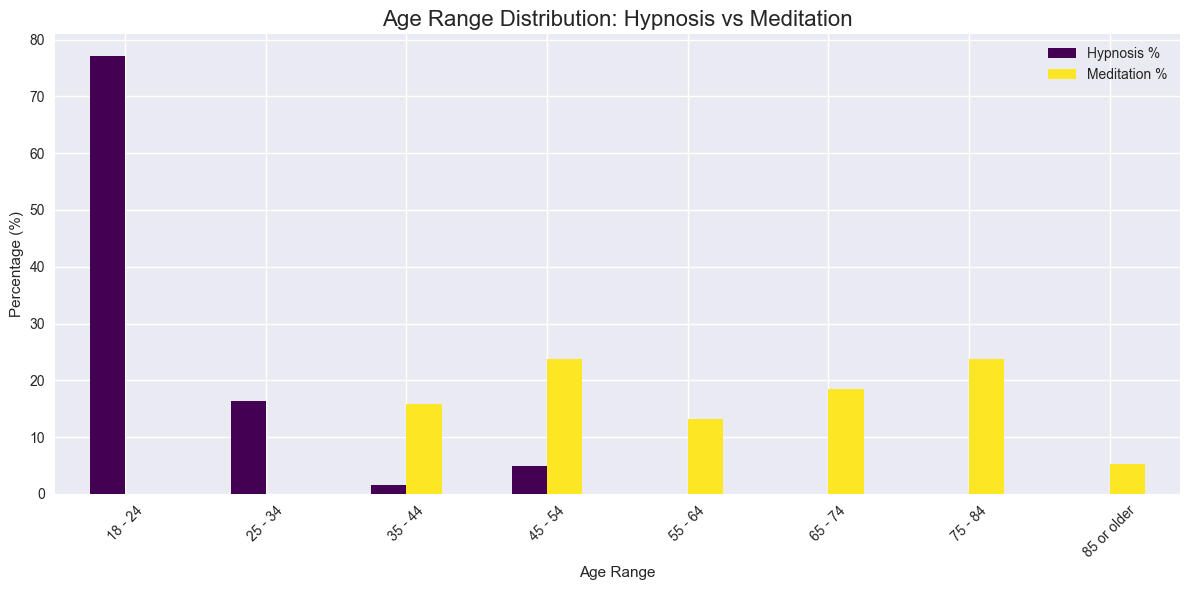

In [105]:
plt.style.use('seaborn-v0_8')

plot_df.plot(kind='bar', figsize=(12, 6), colormap='viridis')

plt.title("Age Range Distribution: Hypnosis vs Meditation", fontsize=16)
plt.xlabel("Age Range")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

GENDER DISTRIBUTION 

In [106]:
# Standardize gender column names
hypnosis_masterdata.columns = hypnosis_masterdata.columns.str.strip().str.lower()
meditation_combined.columns = meditation_combined.columns.str.strip().str.lower()

# Clean gender values (remove spaces, unify case)
hypnosis_masterdata['gender'] = hypnosis_masterdata['gender'].astype(str).str.strip().str.title()
meditation_combined['gender'] = meditation_combined['gender'].astype(str).str.strip().str.title()


In [107]:
# Counts
gender_hyp = hypnosis_masterdata['gender'].value_counts()
gender_med = meditation_combined['gender'].value_counts()

# Percentages
gender_hyp_pct = (gender_hyp / gender_hyp.sum() * 100).round(2)
gender_med_pct = (gender_med / gender_med.sum() * 100).round(2)

print("Dataset A Gender Distribution:")
print(pd.DataFrame({"Count": gender_hyp, "Percent": gender_hyp_pct}))

print("\nMerged Dataset B Gender Distribution:")
print(pd.DataFrame({"Count": gender_med, "Percent": gender_med_pct}))


Dataset A Gender Distribution:
        Count  Percent
gender                
Female     46    75.41
Male       15    24.59

Merged Dataset B Gender Distribution:
               Count  Percent
gender                       
Male              49    73.13
Female            15    22.39
Not Available      2     2.99
Excluded           1     1.49


In [111]:

# Add dataset labels
hypnosis_gender = hypnosis_masterdata[['gender']].copy()
hypnosis_gender['dataset'] = 'Hypnosis'

meditation_gender = meditation_combined[['gender']].copy()
meditation_gender['dataset'] = 'Meditation'

# Combine
gender_long = pd.concat([hypnosis_gender, meditation_gender], ignore_index=True)


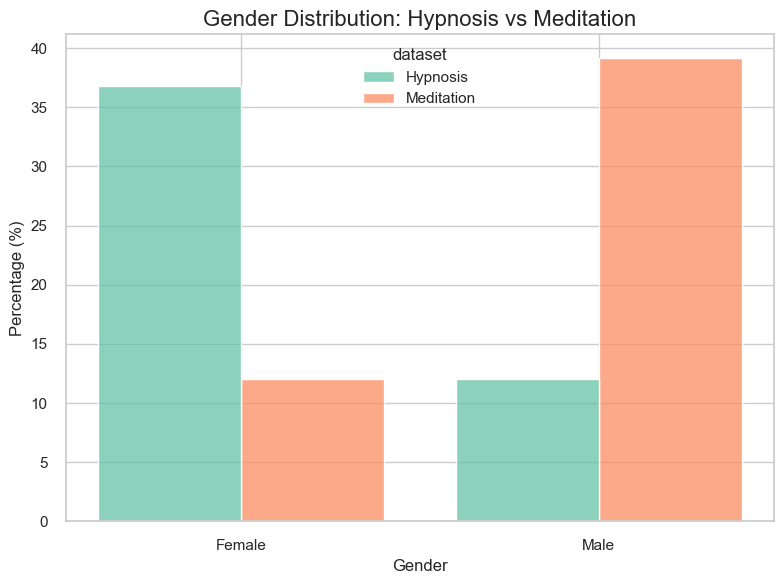

In [115]:
import seaborn as sns
import matplotlib.pyplot as plt

# Remove unwanted categories
gender_long_filtered = gender_long[~gender_long['gender'].isin(['Excluded', 'Not Available'])]

plt.figure(figsize=(8, 6))

sns.histplot(
    data=gender_long_filtered,
    x='gender',
    hue='dataset',
    stat='percent',
    multiple='dodge',
    shrink=0.8,
    palette='Set2'
)
sns.set_theme(style="whitegrid")

plt.title("Gender Distribution: Hypnosis vs Meditation", fontsize=16)
plt.xlabel("Gender")
plt.ylabel("Percentage (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


HYPNOTIZABILITY SCORE

In [116]:
hypnosis_masterdata.columns = hypnosis_masterdata.columns.str.strip().str.lower()

In [117]:
desc = hypnosis_masterdata['hypnotizability_total'].describe()

hypno_stats = pd.DataFrame({
    "Mean": [desc['mean']],
    "Median": [desc['50%']],
    "Std Dev": [desc['std']],
    "Min": [desc['min']],
    "25%": [desc['25%']],
    "75%": [desc['75%']],
    "Max": [desc['max']]
})

print(hypno_stats)


       Mean  Median   Std Dev  Min  25%  75%   Max
0  5.730769     6.0  2.529166  1.0  4.0  7.0  10.0


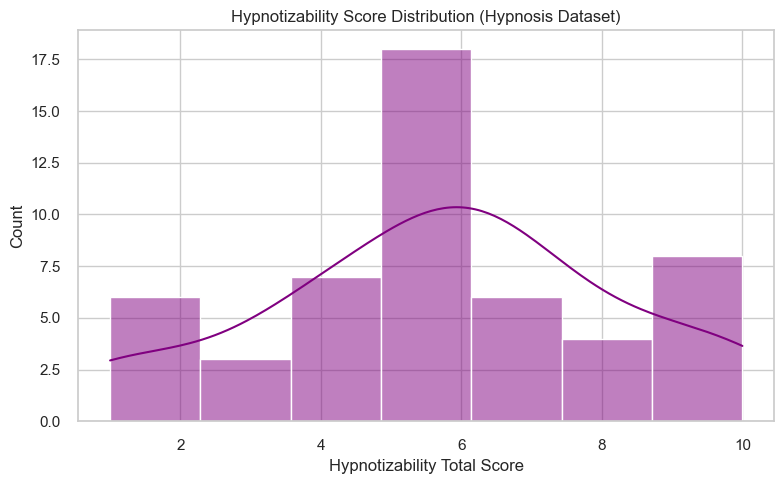

In [118]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.histplot(hypnosis_masterdata['hypnotizability_total'], kde=True, color='purple')

plt.title("Hypnotizability Score Distribution (Hypnosis Dataset)")
plt.xlabel("Hypnotizability Total Score")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


HOURS OF MEDITATION AND AGES 

C:\Users\tramy\AppData\Local\Temp\ipykernel_27512\527693931.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_hours, x='Tradition', y='Hours', palette='Set2')


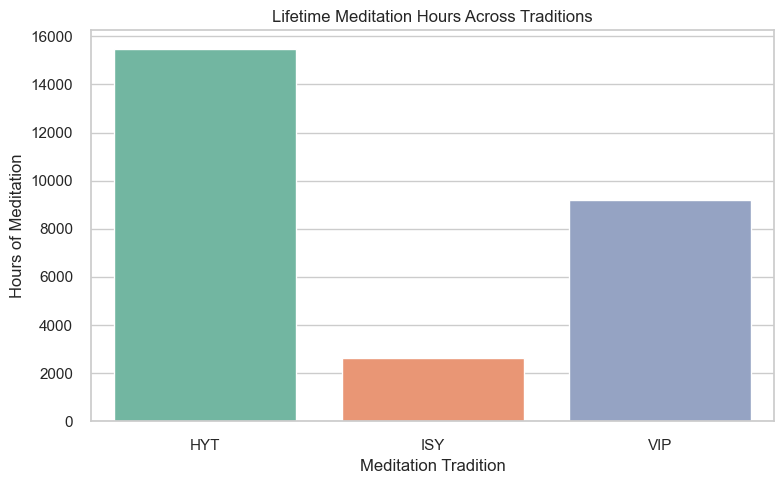

In [120]:
import seaborn as sns
import matplotlib.pyplot as plt

# Example DataFrame
df_hours = pd.DataFrame({
    'Tradition': [ 'HYT', 'ISY', 'VIP'],
    'Hours': [15475, 2625, 9201]
})

plt.figure(figsize=(8,5))
sns.barplot(data=df_hours, x='Tradition', y='Hours', palette='Set2')

plt.title("Lifetime Meditation Hours Across Traditions")
plt.ylabel("Hours of Meditation")
plt.xlabel("Meditation Tradition")
plt.tight_layout()
plt.show()
